# Build a Classification Model with XGBOOST

In [2]:
from collections import namedtuple
from datetime import datetime
import time
import warnings

import numpy as np
import pandas as pd
from sklearn import feature_selection
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
import xgboost as xgb

#from src.plots import plot_feature_importances

label_names = ["non-smoker", "smoker"] # 0 = non-smoker and 1 = smoker
random_state = 111

## Load Normalized Training/Test Data From Preprocessing Notebook

In [4]:
X_train_df = pd.read_csv("output/train_data_normalized.csv")
X_test_df = pd.read_csv("output/test_data_normalized.csv")
y_train_df = pd.read_csv("output/train_labels.csv")
y_test_df = pd.read_csv("output/test_labels.csv")
features = X_train_df.columns

X_train = X_train_df.to_numpy()
X_test = X_test_df.to_numpy()
y_train = y_train_df.to_numpy().ravel()
y_test = y_test_df.to_numpy().ravel()

In [5]:
X_train_df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,0.538462,0.363636,0.190476,0.307692,0.071429,0.091837,0.0,0.0,0.141975,0.141509,...,0.033300,0.124260,0.079075,0.49375,0.0,0.060870,0.014760,0.003776,0.008024,0.0
1,0.461538,0.454545,0.380952,0.512821,0.112245,0.010204,0.0,0.0,0.302469,0.377358,...,0.085772,0.091716,0.090909,0.73125,0.0,0.086957,0.027675,0.009955,0.038114,0.0
2,0.230769,0.545455,0.428571,0.551282,0.142857,0.091837,0.0,0.0,0.364198,0.358491,...,0.235116,0.035503,0.051103,0.56875,0.0,0.069565,0.015683,0.006866,0.061184,0.0
3,0.307692,0.636364,0.380952,0.435897,0.112245,0.142857,0.0,0.0,0.290123,0.358491,...,0.175580,0.136095,0.076385,0.65625,0.0,0.095652,0.011993,0.004119,0.016048,0.0
4,0.307692,0.545455,0.380952,0.461538,0.142857,0.112245,0.0,0.0,0.364198,0.377358,...,0.114026,0.121302,0.074771,0.63750,0.0,0.069565,0.011070,0.004806,0.028084,0.0


## Build A Baseline Model With No Parameter Tuning

In [7]:
starter_model = xgb.XGBClassifier(use_label_encoder=False, random_state=random_state)
starter_model.fit(X_train, y_train)
starter_model_preds = starter_model.predict(X_test)
print(f"Training: {starter_model.score(X_train, y_train)}, Testing: {starter_model.score(X_test, y_test)}\n")
print(classification_report(y_test, starter_model_preds, target_names=label_names))

C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:43:04] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training: 0.8746593131753615, Testing: 0.7715788123637296

              precision    recall  f1-score   support

  non-smoker       0.82      0.81      0.82      4960
      smoker       0.68      0.70      0.69      2837

    accuracy                           0.77      7797
   macro avg       0.75      0.76      0.75      7797
weighted avg       0.77      0.77      0.77      7797



Right away we are outperforming our baseline model - with a testing score of 77% and we are within an acceptable range between training and test regarding overfitting although we are right on the line.

Let's look at feature importance

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

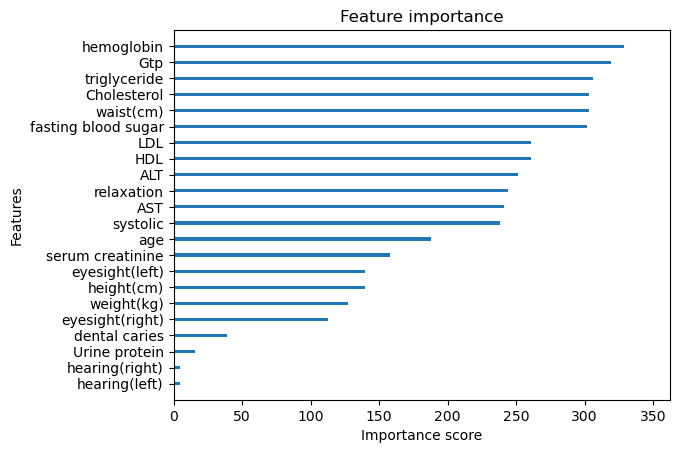

In [9]:
#plot_feature_importances(starter_model, len(X_train_df.columns), X_train_df.columns)
starter_model.get_booster().feature_names = list(features)
xgb.plot_importance(starter_model, grid=False, show_values=False)

We were surprised to see that Height had somewhat with high feature importance.

It doesn't really make much sense to have it in our dataset. In reality, it wouldn't help us accurately diagnose smokers.

In [11]:
#Remove height variable and run the model again
X_train_drop_height_df = X_train_df.drop(["height(cm)"], axis=1)
X_test_drop_height_df = X_test_df.drop(["height(cm)"], axis=1)
new_features = X_train_drop_height_df.columns

X_train_drop_height = X_train_drop_height_df.to_numpy()
X_test_drop_height = X_test_drop_height_df.to_numpy()

In [12]:
starter_model = xgb.XGBClassifier(use_label_encoder=False, random_state=random_state)
starter_model.fit(X_train_drop_height, y_train)
starter_model_preds = starter_model.predict(X_test_drop_height)
print(f"Training: {starter_model.score(X_train_drop_height, y_train)}, Testing: {starter_model.score(X_test_drop_height, y_test)}\n")
print(classification_report(y_test, starter_model_preds, target_names=label_names))

C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:43:06] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training: 0.8687273543463623, Testing: 0.7617032191868668

              precision    recall  f1-score   support

  non-smoker       0.81      0.81      0.81      4960
      smoker       0.67      0.67      0.67      2837

    accuracy                           0.76      7797
   macro avg       0.74      0.74      0.74      7797
weighted avg       0.76      0.76      0.76      7797



Our scores went down a little bit, but I believe this will lead to a better model

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

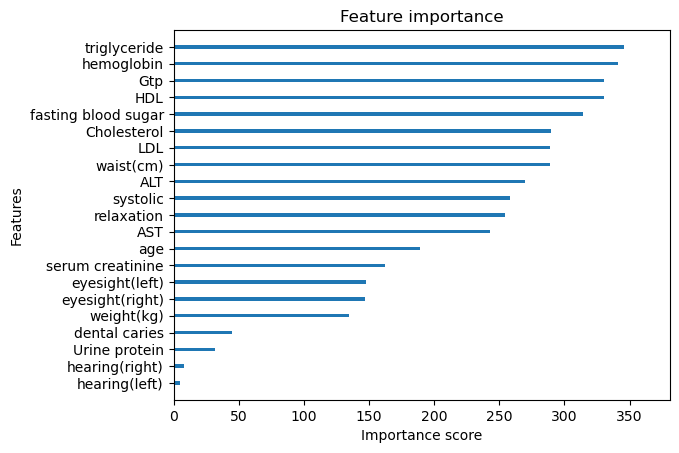

In [14]:
#plot_feature_importances(starter_model, len(X_train_drop_height_df.columns), X_train_drop_height_df.columns)
starter_model.get_booster().feature_names = list(new_features)
xgb.plot_importance(starter_model, grid=False, show_values=False)

Let's see if we can get a better fit or better testing score after tuning the model.

## Build Model with Parameter Tuning

We will be using a range of parameters to try to manage overfitting while finding a good score. We want our model to generalize to real world datasets.

We are using cross-validation, early stopping, roc auc for scoring, max depth (this should help us manage overfitting).

We will be using GridSearchCV to help with testing different parameters to help us find the best parameters

In [17]:
# Determines the number of jobs to run in parallel. -2 will use all but one of your cores. -1 will use all of them.
n_jobs=-2

param_grid = {
    "n_estimators": [500, 750, 1000],
    "max_depth": [5], # 6 is default, higher typically leads to overfitting
    "learning_rate": [0.1, 0.05, 0.3], # 0.3 is default
    "reg_alpha": [0], # l1 regularization, scores > 0, 0 = no regularization
    "reg_lambda": [0, 1, 2], # l2 regularization scores > 0, 0 = no regularization
    "gamma": [0, 1, 10, 100],
    "min_child_weight": [1, 2], # higher values will lead to less overfitting, 1 is default
    "subsample": [0.8, 0.9], # default is 1
    "colsample_bytree": [0.8, 0.9] # default is 1
}

In [18]:
eval_set = [(X_test_drop_height, y_test)]

# ignore the stopped worker warning - this doesn't have any impact on the result of the model and will differ from computer to computer
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", 
        message="A worker stopped while some jobs were given to the executor.*",
        category=UserWarning
    )

    start_time = time.time()
    print(f'Start time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    grid_search = GridSearchCV(
        estimator=xgb.XGBClassifier(use_label_encoder=False, random_state=random_state), 
        param_grid=param_grid, 
        cv=5, 
        n_jobs=n_jobs, 
        verbose=1, 
        scoring="roc_auc"
    )
    grid_search.fit(X_train_drop_height, y_train)

    model = xgb.XGBClassifier(
        **grid_search.best_params_,
        use_label_encoder=False,
        random_state=random_state,
        early_stopping_rounds=10,
    )

    model.fit(
        X_train_drop_height, 
        y_train,
        eval_set=eval_set,
        verbose=0
    )

    model_preds = model.predict(X_test_drop_height)

    print(f"Grid search completed in {time.time() - start_time} seconds\n")
    print(f"\nTraining: {model.score(X_train_drop_height, y_train)}, Testing: {model.score(X_test_drop_height, y_test)}\n")
    print(classification_report(y_test, model_preds, target_names=label_names))

Start time: 2026-06-06 12:43:07
Fitting 5 folds for each of 864 candidates, totalling 4320 fits


C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:39:47] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:48] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Grid search completed in 3402.265397787094 seconds


Training: 0.823612402603649, Testing: 0.7668333974605618

              precision    recall  f1-score   support

  non-smoker       0.81      0.82      0.82      4960
      smoker       0.68      0.67      0.68      2837

    accuracy                           0.77      7797
   macro avg       0.75      0.75      0.75      7797
weighted avg       0.77      0.77      0.77      7797



In [19]:
print(f"\nBest parameters: {grid_search.best_params_}\n")


Best parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 1000, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}



Our overall testing score went down slightly but we have a better fit model.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

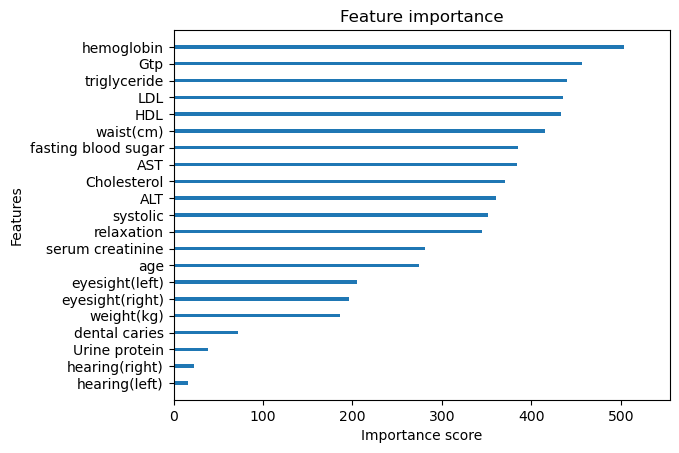

In [21]:
#plot_feature_importances(model, len(X_train_drop_height_df.columns), X_train_drop_height_df.columns)
model.get_booster().feature_names = list(new_features)
xgb.plot_importance(model, grid=False, show_values=False)

Let's see if we can get any additonal accuracy with feature selection

## Build Model with Parameter Tuning + Feature Selection

The function below will iterate through percentages of parameters to keep. It will capture the ROC AUC score and testing score for each iteration.

We will keep the highest testing score.

In [25]:
FeatureSelectionResult = namedtuple("FeatureSelectionResult", ["optimal_percent", "test_score", "roc_auc_cv_score", "selected_features"])

def run_feature_selection(clf, X_train, y_train, X_test, y_test, columns: list, cv=5):
    percentiles = range(1, 100, 5)
    roc_auc_scores_dct = {}
    test_scores_dct = {}
    best_test_score = 0
    best_percentile = 0
    best_features = []
    columns_arr = np.array(columns)
    
    for i in percentiles:
        fs = feature_selection.SelectPercentile(feature_selection.f_classif, percentile=i)
        X_train_fs = fs.fit_transform(X_train, y_train)
        X_test_fs = fs.transform(X_test)
        
        kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
        roc_auc_scores_lst = []
        
        for train_index, val_index in kf.split(X_train_fs):
            X_t, X_val = X_train_fs[train_index], X_train_fs[val_index]
            y_t, y_val = y_train[train_index], y_train[val_index]
            
            eval_set = [(X_val, y_val)]
            clf.fit(X_t, y_t, eval_set=eval_set, verbose=False)
            y_pred_val = clf.predict(X_val)
            roc_auc = roc_auc_score(y_val, y_pred_val)
            roc_auc_scores_lst.append(roc_auc)
        
        clf.fit(X_train_fs, y_train, eval_set=[(X_test_fs, y_test)], verbose=False)
        train_score = clf.score(X_train_fs, y_train)
        test_score = clf.score(X_test_fs, y_test)
        
        roc_auc_scores_dct[i] = np.mean(roc_auc_scores_lst)
        test_scores_dct[i] = test_score
        print(f"Percentage {i}: CV ROC AUC = {np.mean(roc_auc_scores_lst):.3f}, Test Score = {test_score:.3f}, Train score = {train_score:.3f}")

        if test_score > best_test_score:
            best_test_score = test_score
            best_percentile = i
            best_features = columns_arr[fs.get_support(indices=True)]

    return FeatureSelectionResult(optimal_percent=best_percentile, test_score=best_test_score, roc_auc_cv_score=roc_auc_scores_dct[best_percentile], selected_features=list(best_features))

In [26]:
fs_results = run_feature_selection(clf=xgb.XGBClassifier(
    **grid_search.best_params_,
    use_label_encoder=False,
    random_state=random_state,
    early_stopping_rounds=10,
    ), 
    X_train=X_train_drop_height, 
    y_train=y_train, 
    X_test=X_test_drop_height, 
    y_test=y_test,
    columns=X_train_drop_height_df.columns
)

C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928

Percentage 1: CV ROC AUC = 0.665, Test Score = 0.690, Train score = 0.686


C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:50] WARNING: C:\Users\task_177928

Percentage 6: CV ROC AUC = 0.659, Test Score = 0.689, Train score = 0.684


C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:51] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:51] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:51] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:39:51] WARNING: C:\Users\task_177928

...

Percentage 86: CV ROC AUC = 0.730, Test Score = 0.762, Train score = 0.799


C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:20] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:21] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:21] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:21] WARNING: C:\Users\task_177928

Percentage 91: CV ROC AUC = 0.732, Test Score = 0.770, Train score = 0.840


C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:23] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:24] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:24] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:25] WARNING: C:\Users\task_177928

Percentage 96: CV ROC AUC = 0.731, Test Score = 0.758, Train score = 0.799


In [27]:
list(set(X_train_drop_height_df.columns) - set(fs_results.selected_features))

['Urine protein', 'hearing(right)']

It looks like we are droping the hearing and Urine protein variables.

Hearing makes sense intuitively. Urine protein was less obvious to us. We would need to consult a doctor about the correlation between Urine protein and smoking habits.

In [57]:
print(f"Number of features kept: {len(fs_results.selected_features)}")
print(f"Percent of features kept: {fs_results.optimal_percent}%")
new_features = fs_results.selected_features

Number of features kept: 19
Percent of features kept: 91%


In [30]:
#Run the model again with the selected features
X_train_selected = X_train_drop_height_df[fs_results.selected_features].to_numpy()
X_test_selected = X_test_drop_height_df[fs_results.selected_features].to_numpy()

eval_set = [(X_test_selected, y_test)]

model = xgb.XGBClassifier(
    **grid_search.best_params_,
    use_label_encoder=False,
    random_state=random_state,
    early_stopping_rounds=10,
)

model.fit(
    X_train_selected, 
    y_train,
    eval_set=eval_set,
    verbose=0
)

model_preds = model.predict(X_test_selected)
print(f"\nTraining: {model.score(X_train_selected, y_train)}, Testing: {model.score(X_test_selected, y_test)}\n")
print(classification_report(y_test, model_preds, target_names=label_names))

C:\Users\jclen\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:40:27] WARNING: C:\Users\task_177928955923264\croot\xgboost-split_1779289629434\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



Training: 0.8397729823323821, Testing: 0.7696549955110941

              precision    recall  f1-score   support

  non-smoker       0.82      0.82      0.82      4960
      smoker       0.69      0.67      0.68      2837

    accuracy                           0.77      7797
   macro avg       0.75      0.75      0.75      7797
weighted avg       0.77      0.77      0.77      7797



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

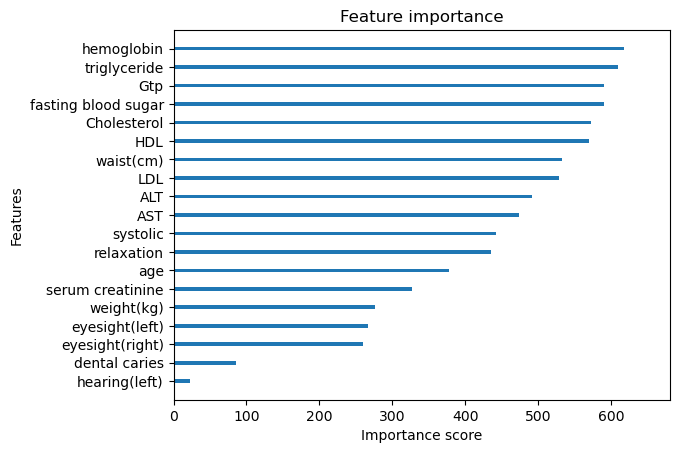

In [31]:
#plot_feature_importances(model, len(fs_results.selected_features), fs_results.selected_features)
model.get_booster().feature_names = list(new_features)
xgb.plot_importance(model, grid=False, show_values=False)

-------------------------

## Observations and Best Model Specifications/Results
Through parameter tuning and feature selection, we were able to find a model that increased the testing score (outperforming our benchmark decision tree) while not overfitting.

In [34]:
print("Model specs:")
print("Params to use with Classifier: ")
print(grid_search.best_params_)
print("Use early stopping rounds of 10 to avoid overfitting")

Model specs:
Params to use with Classifier: 
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 1000, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}
Use early stopping rounds of 10 to avoid overfitting


In [35]:
print("\nResults:\n")
print(f"Training: {model.score(X_train_selected, y_train)}, Testing: {model.score(X_test_selected, y_test)}\n")
print(classification_report(y_test, model_preds, target_names=label_names))


Results:

Training: 0.8397729823323821, Testing: 0.7696549955110941

              precision    recall  f1-score   support

  non-smoker       0.82      0.82      0.82      4960
      smoker       0.69      0.67      0.68      2837

    accuracy                           0.77      7797
   macro avg       0.75      0.75      0.75      7797
weighted avg       0.77      0.77      0.77      7797

